# Step 1.1 — NAIP Tile Download & Data Prep

Downloads raw NAIP COG tiles **directly from AWS Open Data** via STAC — no GEE, no GCS, no egress cost.
Stitches into a GDAL VRT for downstream pixel-level segmentation.

**Data source:** `s3://naip-analytic/` (public, free) via Element84 STAC `earth-search.aws.element84.com/v1`

**Output:** `outputs/segmentation/nyc_segmentation_2022/naip_tiles/`
- `*.tif` — individual NAIP COG tiles (R, G, B, NIR at 1m)
- `naip_2022_nyc.vrt` — GDAL virtual raster (seamless mosaic)
- `naip_2022_nyc.json` — sidecar: band order, CRS, bounds, tile count

> GEE is **not needed** for this step. It is initialized in later steps (1.3 NLCD masks).

## Cell 1 — Imports & Config

In [2]:
from pathlib import Path

from vacant_lot.config import load_config, _get_shared_root
from vacant_lot.tile_export import (
    download_naip_tiles,
    merge_tiles_to_vrt,
    query_naip_stac,
)

SHARED_ROOT = _get_shared_root()

config = load_config("nyc_buildings.yaml")

print(f"City:      {config.city_name}")
print(f"Run key:   {config._run_key()}")
print(f"NAIP year: {config.naip.year}")
print(f"bbox:      {config.segmentation.bbox}")

19:42:09 | INFO | vacant_lots | Loaded config for: nyc_buildings.yaml
City:      New York City
Run key:   nyc_buildings
NAIP year: 2022
bbox:      (-74.27, 40.49, -73.7, 40.92)


## Cell 2 — Create Output Directories

In [3]:
config.ensure_seg_output_dirs()
tiles_dir = config.get_naip_tiles_dir()
print(f"Tiles dir: {tiles_dir}")

Tiles dir: /path/to/Vacant_Lot_Detection/outputs/segmentation/nyc_buildings/naip_tiles


## Cell 3 — Query NAIP STAC

No credentials needed — `naip-analytic` is a public AWS Open Data bucket indexed by Element84.

In [4]:
bbox = config.segmentation.bbox  # (west, south, east, north)

items = query_naip_stac(
    bbox=bbox,
    year=config.naip.year,
)

print(f"Found {len(items)} NAIP tiles")
print(f"Example item: {items[0].id}")
print(f"Assets: {list(items[0].assets.keys())}")

19:42:31 | INFO | vacant_lots | Querying Planetary Computer NAIP STAC for year=2022, bbox=(-74.27, 40.49, -73.7, 40.92)
19:42:33 | INFO | vacant_lots | Found 85 NAIP tiles
Found 85 NAIP tiles
Example item: ny_m_4007439_nw_18_060_20221007
Assets: ['image', 'thumbnail', 'tilejson', 'rendered_preview']


## Cell 4 — Download Tiles from S3

Downloads from -----
**MAC: run caffeinate -i in any terminal for this long running task**

In [5]:
local_tile_paths = download_naip_tiles(
    items=items,
    local_dir=tiles_dir,
)

print(f"Downloaded {len(local_tile_paths)} tiles to {tiles_dir}")
print(f"Disk usage: {sum(p.stat().st_size for p in local_tile_paths) / 1e9:.2f} GB")

19:42:36 | INFO | vacant_lots | [1/85] Skipping (exists): ny_m_4007439_nw_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [2/85] Skipping (exists): ny_m_4007438_ne_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [3/85] Skipping (exists): ny_m_4007431_sw_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [4/85] Skipping (exists): ny_m_4007431_nw_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [5/85] Skipping (exists): ny_m_4007430_se_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [6/85] Skipping (exists): ny_m_4007423_sw_18_060_20221007.tif
19:42:36 | INFO | vacant_lots | [7/85] Skipping (exists): ny_m_4007432_sw_18_060_20220915.tif
19:42:36 | INFO | vacant_lots | [8/85] Skipping (exists): ny_m_4007432_nw_18_060_20220915.tif
19:42:36 | INFO | vacant_lots | [9/85] Skipping (exists): ny_m_4007431_se_18_060_20220915.tif
19:42:36 | INFO | vacant_lots | [10/85] Skipping (exists): ny_m_4007431_ne_18_060_20220915.tif
19:42:36 | INFO | vacant_lots | [11/85] Skipping (exists): 

## Cell 5 — Build GDAL VRT

In [6]:
output_vrt = tiles_dir / "naip_2022_nyc.vrt"

vrt_path = merge_tiles_to_vrt(
    tile_paths=local_tile_paths,
    output_vrt=output_vrt,
)

print(f"VRT created: {vrt_path}")

19:42:47 | INFO | vacant_lots | Building VRT from 85 tiles → /path/to/Vacant_Lot_Detection/outputs/segmentation/nyc_buildings/naip_tiles/naip_2022_nyc.vrt
19:42:47 | INFO | vacant_lots | VRT created
19:42:47 | INFO | vacant_lots | Sidecar: /path/to/Vacant_Lot_Detection/outputs/segmentation/nyc_buildings/naip_tiles/naip_2022_nyc.json
VRT created: /path/to/Vacant_Lot_Detection/outputs/segmentation/nyc_buildings/naip_tiles/naip_2022_nyc.vrt


## Cell 6 — Verification

{
  "tile_count": 85,
  "band_order": [
    "R",
    "G",
    "B",
    "NIR"
  ],
  "crs": "EPSG:26918",
  "bounds": [
    557694.021778,
    4476342.0,
    611310.021778,
    4532850.0
  ]
}

VRT shape:  94180 × 89360 px
Band count: 4  (expected 4: R, G, B, NIR)
CRS:        EPSG:26918
Bounds:     BoundingBox(left=557694.021778, bottom=4476342.0, right=611310.021778, top=4532850.0)


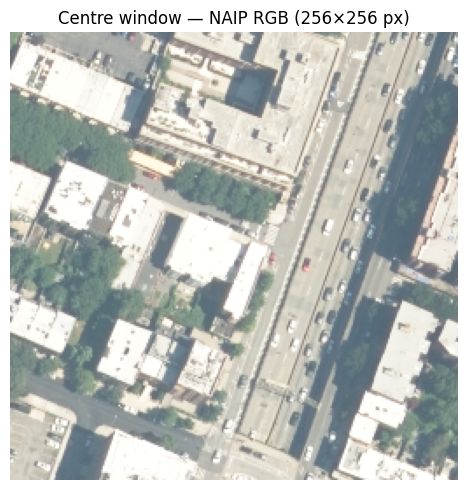

Verification passed.


In [7]:
import json
import numpy as np
import rasterio
from rasterio.windows import Window
import matplotlib.pyplot as plt

# Print sidecar
sidecar = json.loads(vrt_path.with_suffix(".json").read_text())
print(json.dumps(sidecar, indent=2))

with rasterio.open(vrt_path) as ds:
    print(f"\nVRT shape:  {ds.height} × {ds.width} px")
    print(f"Band count: {ds.count}  (expected 4: R, G, B, NIR)")
    print(f"CRS:        {ds.crs}")
    print(f"Bounds:     {ds.bounds}")

    assert ds.count == 4, f"Expected 4 bands, got {ds.count}"

    # Read 256×256 window from centre
    cx, cy = ds.width // 2, ds.height // 2
    window = Window(cx - 128, cy - 128, 256, 256)
    rgb = ds.read([1, 2, 3], window=window)  # R, G, B

assert rgb.max() > 0, "Window is all-zero — check tile coverage"
assert 0 <= rgb.min() and rgb.max() <= 255

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(np.moveaxis(rgb, 0, -1))
ax.set_title("Centre window — NAIP RGB (256×256 px)")
ax.axis("off")
plt.tight_layout()
plt.show()

print("Verification passed.")

---
## Tests

Scratch cells for manual inspection — outputs go to `./tmp/` (gitignored).

In [6]:
# Build one VRT per acquisition date for QGIS inspection
# Output: tmp/naip_vrt_date_tests/ (gitignored)
# Paths inside each VRT are rewritten to absolute so QGIS resolves tiles correctly.
import xml.etree.ElementTree as ET
from collections import defaultdict

def make_vrt_paths_absolute(vrt_path: Path) -> None:
    """Rewrite all SourceFilename entries in a VRT to absolute paths."""
    tree = ET.parse(vrt_path)
    root = tree.getroot()
    vrt_dir = vrt_path.parent.resolve()
    for elem in root.iter("SourceFilename"):
        raw = elem.text.strip()
        resolved = (vrt_dir / raw).resolve()
        elem.set("relativeToVRT", "0")
        elem.text = str(resolved)
    tree.write(vrt_path)

out_dir = (SHARED_ROOT / "tmp" / "naip_vrt_date_tests").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

by_date = defaultdict(list)
for p in tiles_dir.glob("*.tif"):
    date = p.stem.split("_")[-1]
    by_date[date].append(p)

for date, tiles in sorted(by_date.items()):
    vrt = out_dir / f"naip_{date}.vrt"
    merge_tiles_to_vrt(tiles, vrt)
    make_vrt_paths_absolute(vrt)
    print(f"{date}: {len(tiles)} tiles → {vrt}")

16:57:03 | INFO | vacant_lots | Building VRT from 18 tiles → /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220710.vrt
16:57:04 | INFO | vacant_lots | VRT created
16:57:04 | INFO | vacant_lots | Sidecar: /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220710.json
20220710: 18 tiles → /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220710.vrt
16:57:04 | INFO | vacant_lots | Building VRT from 17 tiles → /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220719.vrt
16:57:04 | INFO | vacant_lots | VRT created
16:57:04 | INFO | vacant_lots | Sidecar: /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220719.json
20220719: 17 tiles → /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220719.vrt
16:57:04 | INFO | vacant_lots | Building VRT from 18 tiles → /path/to/Vacant_Lot_Detection/tmp/naip_vrt_date_tests/naip_20220720.vrt
16:57:04 | INFO | vacant_lots | VRT created
16:57:04 | INFO | vacant_lots | Sidecar: /path/to/Vacan